In [10]:
from ultralytics import YOLO
import os
import media_tools.video_tools as vt
import media_tools.image_tools as it
import ultralytics as sv
import cv2
import matplotlib.pyplot as plt
import torch
from tqdm._tqdm import tqdm
import supervision as sv
import numpy as np


from draw_pitch import get_pitch_image
from draw_pitch import overlay_pitch_minimap
from draw_pitch import draw_keypoints
from homography import get_homography
%load_ext autoreload

%autoreload 2


keypoint_model = YOLO('runs (2)/content/runs/train4/weights/last.pt')
object_detection_model = YOLO(os.path.join("..","object_detection","models","it_2","weights","best.pt"))





The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[autoreload of homography failed: Traceback (most recent call last):
  File "/home/adrian/anaconda3/envs/IA-Futbol/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 283, in check
    superreload(m, reload, self.old_objects)
  File "/home/adrian/anaconda3/envs/IA-Futbol/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 483, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "/home/adrian/anaconda3/envs/IA-Futbol/lib/python3.12/importlib/__init__.py", line 131, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 866, in _exec
  File "<frozen importlib._bootstrap_external>", line 995, in exec_module
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "/home/adrian/IA-Futbol/pitch_keypoints/homography.py", line 2, in <module>
    from .datatools.ellipse import INTERSECTON_TO_PITCH_POINTS
ImportError: attempted relative import with no known parent package


In [6]:
#Funciones auxiliares
def write_image(frame:str):
    annotated_frame = frame.copy()

    #Marcamos objetos
    object_detections = object_detection_model(frame,verbose = False)[0]
    object_detections = sv.Detections.from_ultralytics(object_detections)

    annotated_frame = it.player_annotator(annotated_frame,object_detections[object_detections.class_id == 1],text_label=False)
    annotated_frame = it.player_annotator(annotated_frame,object_detections[object_detections.class_id == 2],text_label=False)
    annotated_frame = it.ball_annotator(annotated_frame,object_detections[object_detections.class_id == 0])

    #Keypoints
    kpts = keypoint_model(frame,verbose = False)[0]
    annotated_frame = draw_keypoints(annotated_frame,kpts.keypoints.data)

    #Calculamos Homografia: Pixeles a Mapa2D

 
    H = get_homography(kpts.keypoints.data)

    pitch_imgage  = get_pitch_image() #Mapa 2D vacío

    if H is not None:
        #Calculamos posiciones de los jugadores
        player_detections = object_detections[object_detections.class_id == 1]
        player_centers = player_detections.get_anchors_coordinates(anchor=sv.Position.BOTTOM_CENTER) #los pies
        player_centers = np.array(player_centers, dtype=np.float32).reshape(-1, 1, 2) #(N,2) -> (N,1,2) para cv2

        if len(player_centers >= 1):
            player_centers_2dmap = cv2.perspectiveTransform(player_centers, H)
            player_centers_2dmap = player_centers_2dmap.reshape(-1, 2) #(N,1,2) -> (N,2)

            
            pitch_imgage = get_pitch_image(players_keypoints=player_centers_2dmap)
            

    annotated_frame = overlay_pitch_minimap(annotated_frame,pitch_imgage)

    return annotated_frame,pitch_imgage



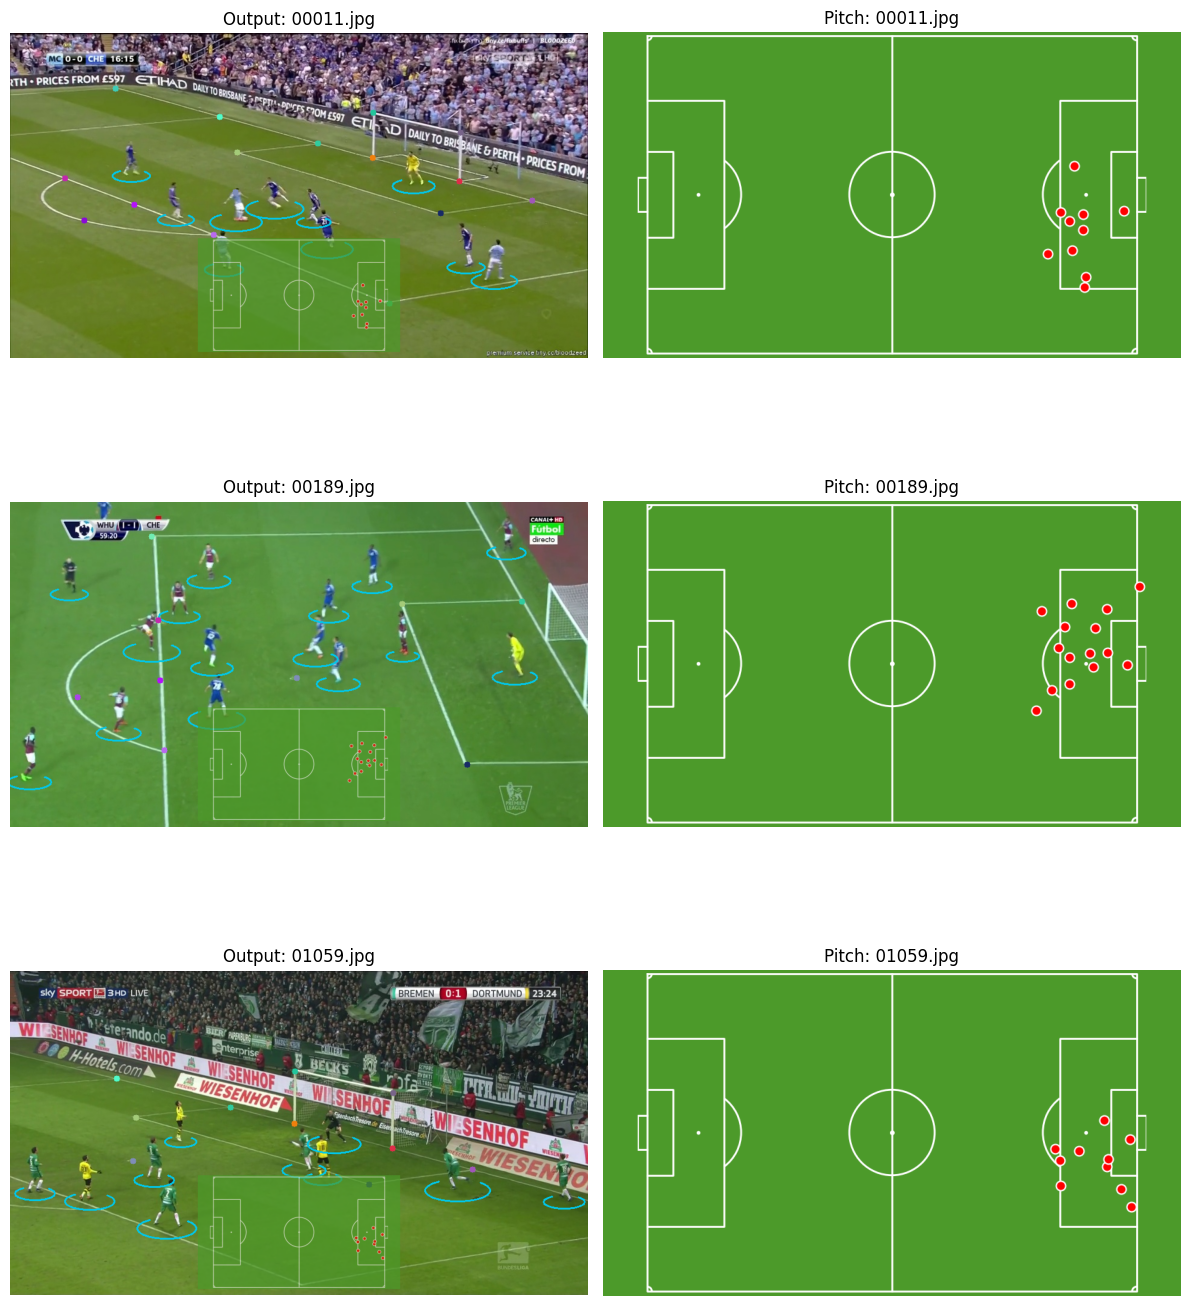

In [7]:
#===============================
#VARIAS IMAGENES
#===============================

base_path = os.path.join("dataset", "challenge")
img_names = ["00011.jpg", "00189.jpg", "01059.jpg"] 

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 15))

for i, img_name in enumerate(img_names):
    img_path = os.path.join(base_path, img_name)
    img_bgr = cv2.imread(img_path)
    
    if img_bgr is None:
        print(f"No se pudo cargar {img_name}")
        continue
        
   
    output, pitch_img = write_image(img_bgr)
    
   
    output_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)
    pitch_rgb = cv2.cvtColor(pitch_img, cv2.COLOR_BGR2RGB)
    
    # Mostrar en la columna 1: Output
    axes[i, 0].imshow(output_rgb)
    axes[i, 0].set_title(f"Output: {img_name}")
    axes[i, 0].axis('off')
    
    # Mostrar en la columna 2: Pitch Image
    axes[i, 1].imshow(pitch_rgb)
    axes[i, 1].set_title(f"Pitch: {img_name}")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

In [5]:
def write_video(video_path: str, output_path):

    #Video entrada
    video = cv2.VideoCapture(video_path)
    fps = int(video.get(cv2.CAP_PROP_FPS))
    width  = int(video.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    total_frames = int(video.get(cv2.CAP_PROP_FRAME_COUNT))

    ouput =  cv2.VideoWriter(output_path,fourcc,fps,(width,height),isColor=True)
    
    
    H = None

    for num_frames in tqdm(range(total_frames),desc="Processing video"):

    
        #Lee el frame
        ret, frame = video.read()
        
        if not ret:
            break
            
        annotated_frame = frame.copy()
        #Marcamos objetos
        object_detections = object_detection_model(frame,verbose = False)[0]
        object_detections = sv.Detections.from_ultralytics(object_detections)

        annotated_frame = it.player_annotator(annotated_frame,object_detections[object_detections.class_id == 1],text_label=False)
        annotated_frame = it.player_annotator(annotated_frame,object_detections[object_detections.class_id == 2],text_label=False)
        annotated_frame = it.ball_annotator(annotated_frame,object_detections[object_detections.class_id == 0])

        #Keypoints
        kpts = keypoint_model(frame,verbose = False)[0]
        annotated_frame = draw_keypoints(annotated_frame,kpts.keypoints.data)

        #Calculamos Homografia: Pixeles a Mapa2D
        if num_frames % 20 == 0:

            H_new = get_homography(kpts.keypoints.data)

            if H_new is not None :
                H = H_new

        if H is not None:
            #Calculamos posiciones de los jugadores
            player_detections = object_detections[object_detections.class_id == 1]
            player_centers = player_detections.get_anchors_coordinates(anchor=sv.Position.BOTTOM_CENTER) #los pies
            player_centers = np.array(player_centers, dtype=np.float32).reshape(-1, 1, 2) #(N,2) -> (N,1,2) para cv2

            if len(player_centers >= 1):
                player_centers_2dmap = cv2.perspectiveTransform(player_centers, H)
                player_centers_2dmap = player_centers_2dmap.reshape(-1, 2) #(N,1,2) -> (N,2)

            pitch_imgage = get_pitch_image(keypoints=player_centers_2dmap)
        
        else:
            pitch_imgage  = get_pitch_image() #Mapa 2D vacío


        annotated_frame = overlay_pitch_minimap(annotated_frame,pitch_imgage)
        ouput.write(annotated_frame)

    video.release()
    ouput.release()

In [6]:

video_1_path = os.path.join("..","videos","video_1.mp4")
video_2_path = os.path.join("..","videos","video_2.mp4") 
video_3_path = os.path.join("..","videos","video_3.mp4")

keypoint_model.eval()
object_detection_model.eval()

#write_video(video_1_path,output_path=os.path.join("..","videos","pitch_keypoints","video_1.mp4"))
#write_video(video_2_path,output_path=os.path.join("..","videos","pitch_keypoints","video_2.mp4"))
write_video(video_3_path,output_path=os.path.join("..","videos","pitch_keypoints","video_3.mp4"))

Processing video:  97%|█████████▋| 3001/3085 [03:43<00:06, 13.42it/s]
